# ViewCastLK — Thumbnail analysis

The main EDA found that predicting the **within-channel residual** from
pre-publication metadata gives, across eight splits, **mean R² ≈ 0.00 (sd 0.11)**
on held-out channels — indistinguishable from zero. Almost nothing about why one
video outperforms another *from the same channel* is in the dataset.

The thumbnail is the most obvious missing piece. It is the only part of the
pre-publication package a viewer actually looks at before clicking, and until
now only a URL was available.

This notebook asks two questions, and they get different answers:

> 1. **Do thumbnail features explain within-channel over-performance?**
> 2. **Do they help predict views on a channel never seen before?**

Both are falsifiable with a real chance of "no", and every comparison here is
**paired across eight splits** — a single split on this data swings by ±0.1 R²
and would answer whichever way the seed fell.

## What was measured

Cheap, interpretable properties rather than a neural embedding, so a creator
can act on the result: brightness, contrast, saturation, colourfulness,
sharpness, edge density, a text-overlay proxy, face count and face area, warm
/cool balance, and dark/bright pixel shares.

`face_count` comes from OpenCV's Haar cascade, which misses small and side-on
faces — read it as a **lower bound**, not a census.

## The caveat that must travel with every number here

YouTube serves a **replaced** thumbnail from the same URL. For an older video
the image measured today may not be the one it launched with, and there is no
way to detect that — which is exactly why the metadata-change detector covers
titles and descriptions but not thumbnails. §8 tests whether the effects differ
for recently published videos, where the image is likelier to be original.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
mpl.rcParams.update({"figure.figsize": (10, 5), "figure.dpi": 110,
                     "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 10})

FIGS = Path("eda_figures"); FIGS.mkdir(exist_ok=True)
def save(n): plt.tight_layout(); plt.savefig(FIGS/f"{n}.png", bbox_inches="tight")

HORIZON = 7
tf = pd.read_parquet("thumbnail_features.parquet")
from paths import dataset_path
df = pd.read_parquet(dataset_path())

base = df[df.eligible & df[f"d{HORIZON}_usable"]].copy()
base["y"] = np.log1p(base[f"d{HORIZON}_views"])
base["channel_resid"] = base.y - base.groupby("channel_id").y.transform("mean")

d = base.merge(tf, on="video_id", how="inner")
print(f"thumbnails measured        : {len(tf):,}")
print(f"labelled videos available  : {len(base):,}")
print(f"joined for analysis        : {len(d):,}  ({len(d)/len(base):.1%} coverage)")
print(f"channels represented       : {d.channel_id.nunique():,}")

IMG = ["brightness", "contrast", "saturation", "colourfulness", "sharpness",
       "edge_density", "text_band_density", "face_count", "face_area_ratio",
       "warm_ratio", "dark_share", "bright_share", "bytes"]
print(f"\nface detection available: {d.face_count.notna().all()}")

thumbnails measured        : 30,554
labelled videos available  : 30,718
joined for analysis        : 30,554  (99.5% coverage)
channels represented       : 1,932

face detection available: True


## 1. What the thumbnails look like

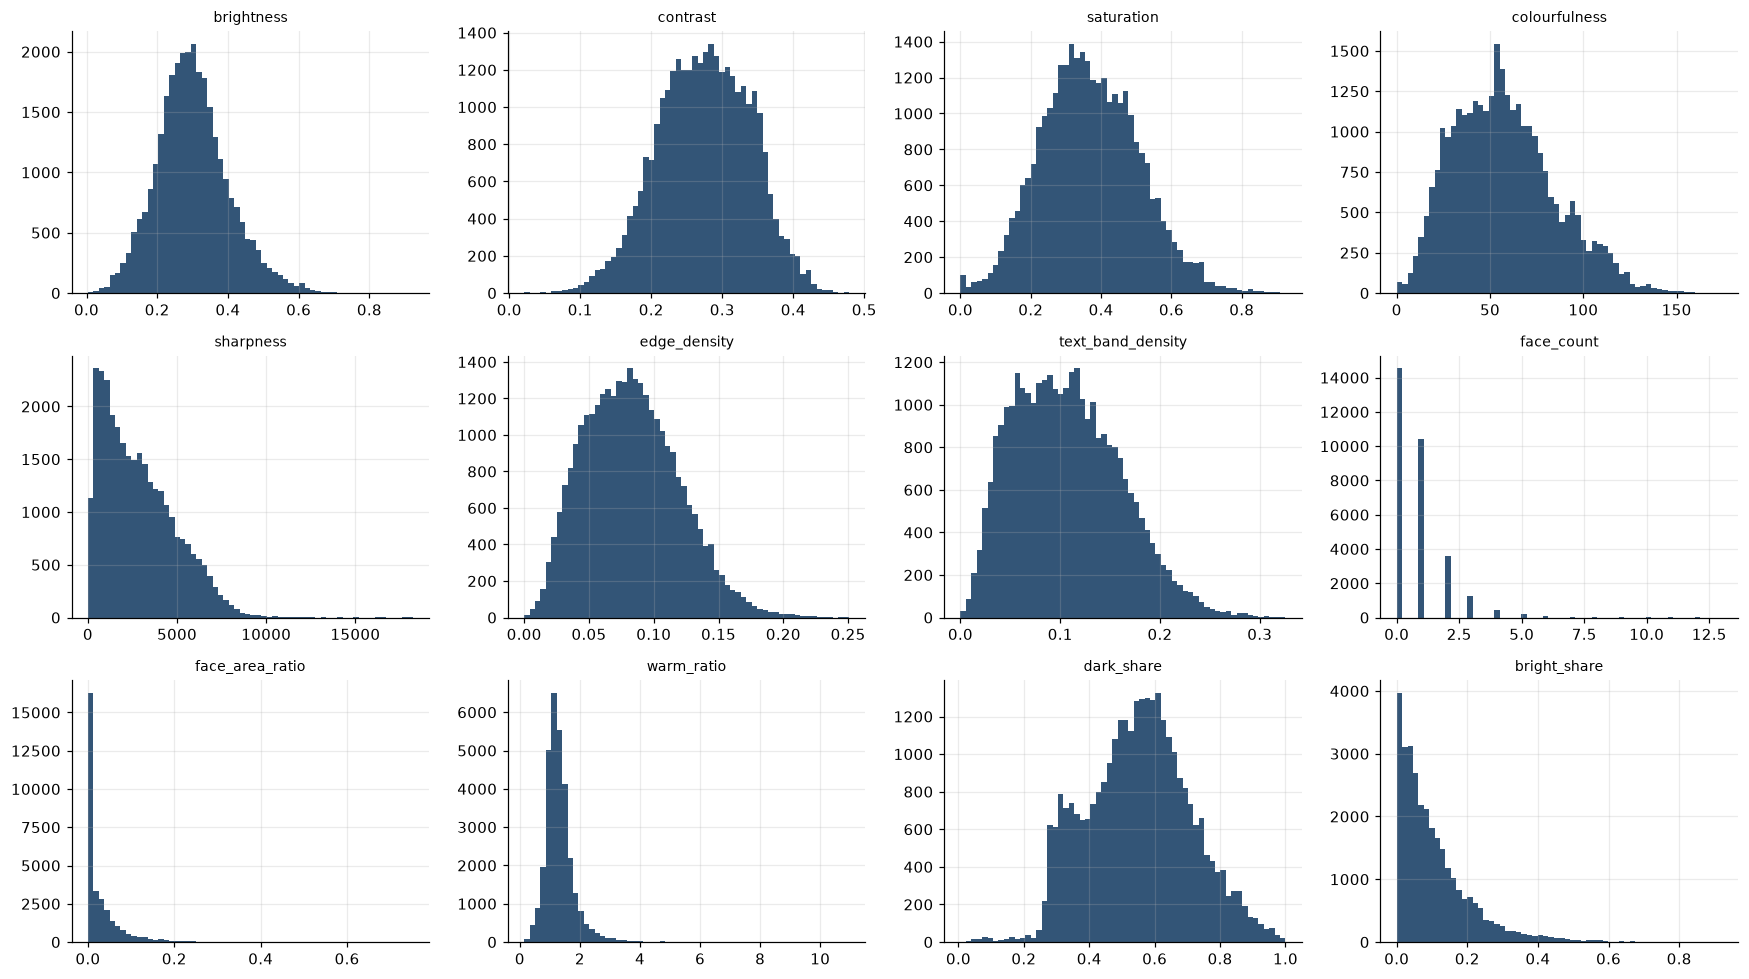

                       count       mean       std       min        10%        50%        90%        max
brightness        30,554.000      0.301     0.102     0.004      0.177      0.294      0.434      0.923
contrast          30,554.000      0.275     0.065     0.021      0.191      0.276      0.357      0.479
saturation        30,554.000      0.369     0.138     0.000      0.195      0.361      0.548      0.924
colourfulness     30,554.000     57.491    27.042     0.000     24.250     55.038     95.447    174.171
sharpness         30,554.000  2,858.631 2,024.432     2.665    556.686  2,485.563  5,802.316 18,229.479
edge_density      30,554.000      0.083     0.036     0.000      0.037      0.081      0.132      0.251
text_band_density 30,554.000      0.107     0.053     0.000      0.041      0.103      0.179      0.326
face_count        30,554.000      0.821     1.074     0.000      0.000      1.000      2.000     13.000
face_area_ratio   30,554.000      0.030     0.056     0.000     

In [2]:
fig, ax = plt.subplots(3, 4, figsize=(16, 9))
for a, c in zip(ax.ravel(), IMG[:12]):
    a.hist(d[c].dropna(), bins=60, color="#357")
    a.set_title(c, fontsize=9)
save("t01_feature_distributions"); plt.show()

print(d[IMG].describe(percentiles=[.1, .5, .9]).T.to_string())
print(f"\nthumbnails containing at least one detected face: {d.has_face.mean():.1%}")
print(f"median faces when present: "
      f"{d.loc[d.face_count > 0, 'face_count'].median():.0f}")

## 2. Do thumbnail properties relate to performance?

Measured against the **within-channel residual**, as everywhere else — a
channel's house style would otherwise make thumbnail features a proxy for
channel identity.

Spearman correlation with within-channel residual:

contrast            -0.065
bright_share        -0.049
brightness          -0.046
dark_share           0.042
saturation           0.037
sharpness           -0.030
warm_ratio          -0.021
face_area_ratio     -0.021
face_count          -0.016
text_band_density   -0.012
edge_density        -0.009
colourfulness       -0.004
bytes               -0.001


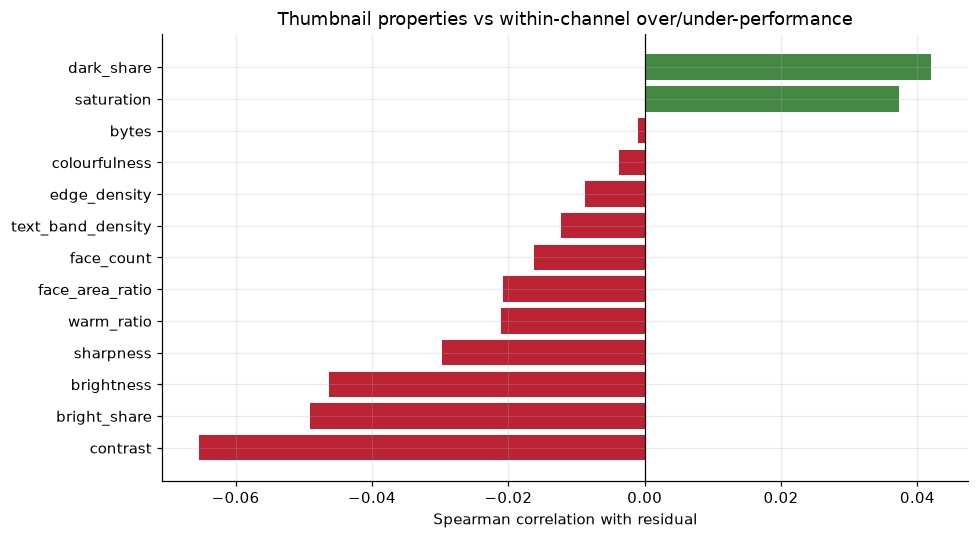

In [3]:
corr = (d[IMG + ["channel_resid"]].corr(method="spearman")["channel_resid"]
          .drop("channel_resid").sort_values(key=abs, ascending=False))
print("Spearman correlation with within-channel residual:\n")
print(corr.to_string())

fig, ax = plt.subplots(figsize=(9, 5))
o = corr.sort_values()
ax.barh(o.index, o.values, color=["#b23" if v < 0 else "#484" for v in o.values])
ax.axvline(0, color="k", lw=.8)
ax.set(xlabel="Spearman correlation with residual",
       title="Thumbnail properties vs within-channel over/under-performance")
save("t02_correlations"); plt.show()

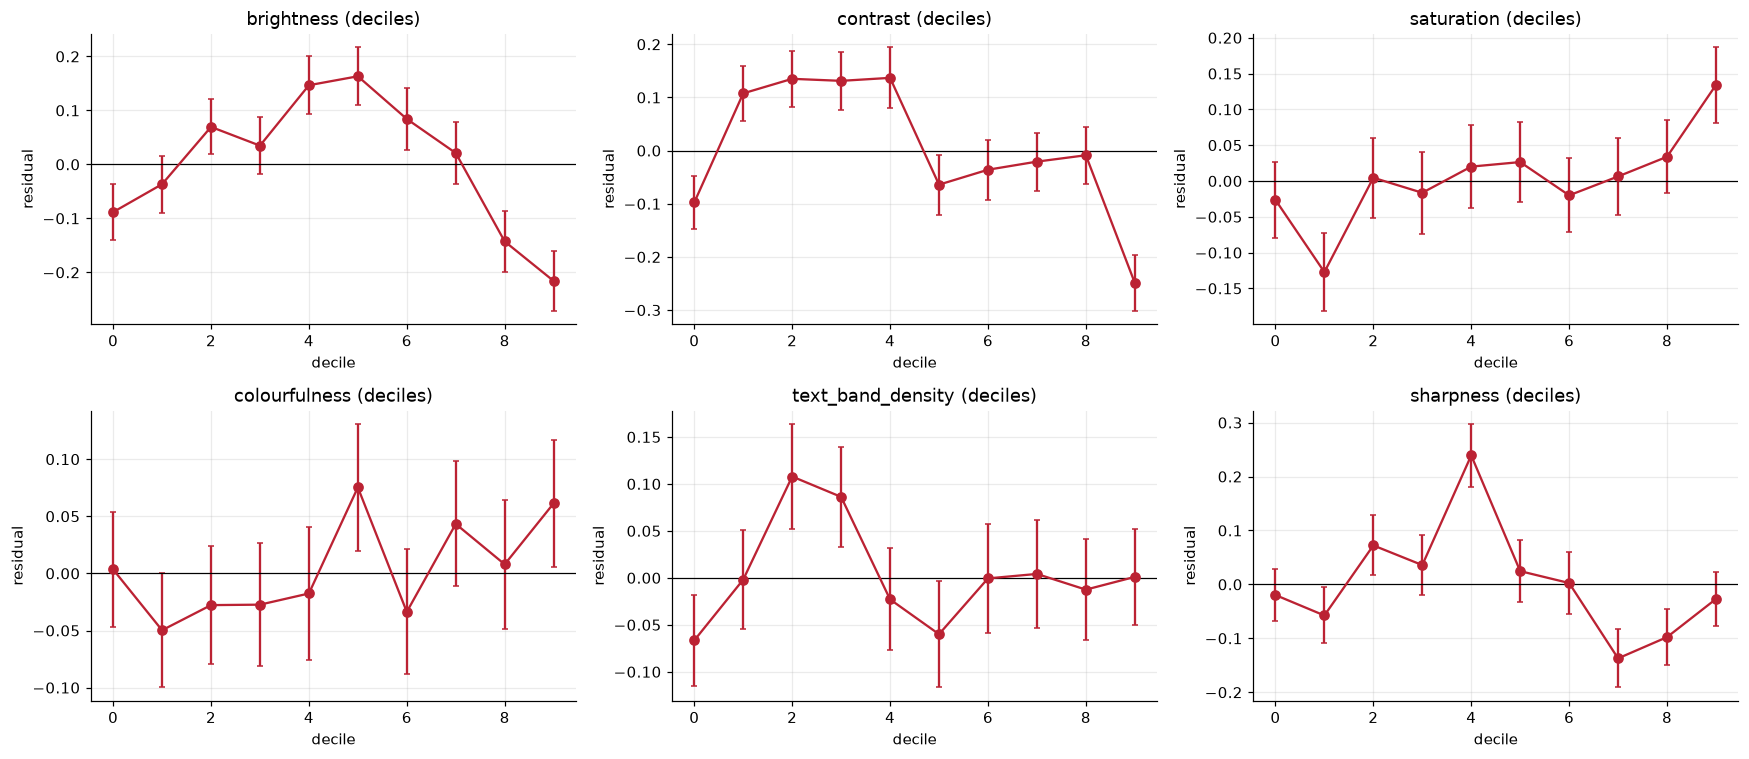

A U or inverted-U here means the correlation above understates the
relationship -- the feature matters but not monotonically.


In [4]:
# Decile profiles: correlation assumes monotonicity, which several of these
# almost certainly violate (mid-brightness may beat both extremes).
show = [c for c in ["brightness", "contrast", "saturation", "colourfulness",
                    "text_band_density", "sharpness"] if c in d]
fig, ax = plt.subplots(2, 3, figsize=(16, 7))
for a, c in zip(ax.ravel(), show):
    b = pd.qcut(d[c], 10, duplicates="drop")
    g = d.groupby(b, observed=True).channel_resid.agg(["size", "mean", "std"])
    g["se"] = g["std"]/np.sqrt(g["size"])
    a.errorbar(range(len(g)), g["mean"], yerr=1.96*g.se, marker="o",
               color="#b23", capsize=2)
    a.axhline(0, color="k", lw=.8)
    a.set(title=f"{c} (deciles)", xlabel="decile", ylabel="residual")
save("t03_decile_profiles"); plt.show()
print("A U or inverted-U here means the correlation above understates the")
print("relationship -- the feature matters but not monotonically.")

## 3. Faces — the feature every thumbnail guide insists on

has_face, all channels:

           size   mean   std    se
has_face                          
False     14553  0.030 1.534 0.013
True      16001 -0.020 1.526 0.012

within channels that use BOTH (1,242 channels):

           size   mean   std    se
has_face                          
False     13940  0.030 1.554 0.013
True      15417 -0.022 1.546 0.012

face effect: -0.0515 log units  (~-5.0% in views)


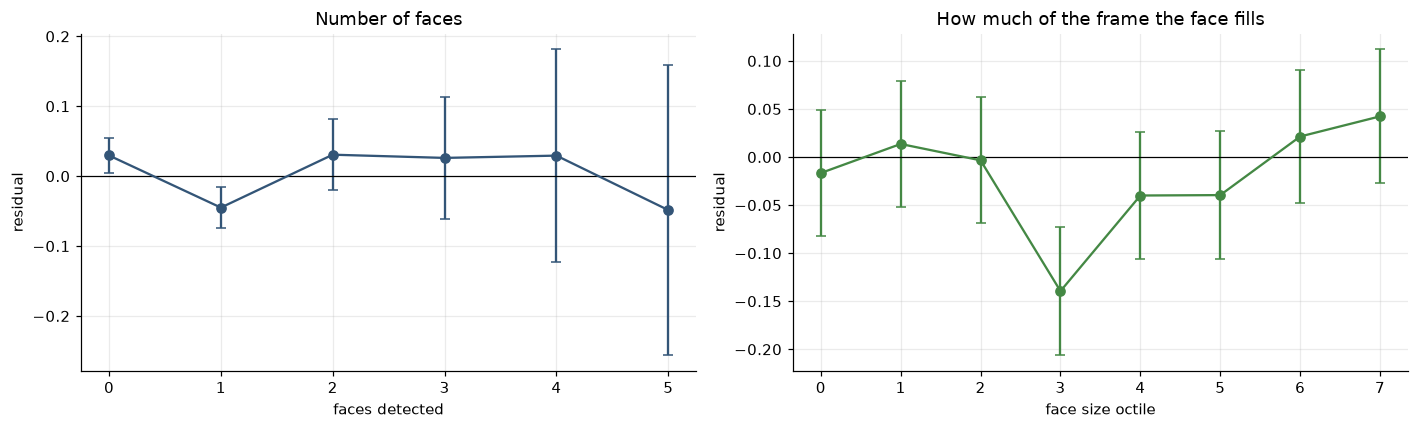

In [5]:
fc = d.groupby("has_face").channel_resid.agg(["size", "mean", "std"])
fc["se"] = fc["std"]/np.sqrt(fc["size"])
print("has_face, all channels:\n"); print(fc.to_string())

# Only channels that vary -- a channel always using faces tells us nothing.
v = d.groupby("channel_id").has_face.nunique()
dv = d[d.channel_id.isin(v[v > 1].index)]
fv = dv.groupby("has_face").channel_resid.agg(["size", "mean", "std"])
fv["se"] = fv["std"]/np.sqrt(fv["size"])
print(f"\nwithin channels that use BOTH ({dv.channel_id.nunique():,} channels):\n")
print(fv.to_string())
eff = fv["mean"].iloc[1] - fv["mean"].iloc[0]
print(f"\nface effect: {eff:+.4f} log units  "
      f"(~{100*(np.exp(eff)-1):+.1f}% in views)")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
g = d[d.face_count <= 5].groupby("face_count").channel_resid.agg(
    ["size", "mean", "std"])
g["se"] = g["std"]/np.sqrt(g["size"])
ax[0].errorbar(g.index, g["mean"], yerr=1.96*g.se, marker="o", capsize=3,
               color="#357")
ax[0].axhline(0, color="k", lw=.8)
ax[0].set(xlabel="faces detected", ylabel="residual", title="Number of faces")

s = d[d.face_area_ratio > 0]
b = pd.qcut(s.face_area_ratio, 8, duplicates="drop")
g2 = s.groupby(b, observed=True).channel_resid.agg(["size", "mean", "std"])
g2["se"] = g2["std"]/np.sqrt(g2["size"])
ax[1].errorbar(range(len(g2)), g2["mean"], yerr=1.96*g2.se, marker="o",
               capsize=3, color="#484")
ax[1].axhline(0, color="k", lw=.8)
ax[1].set(xlabel="face size octile", ylabel="residual",
          title="How much of the frame the face fills")
save("t04_faces"); plt.show()

## 4. Segmented — do thumbnail effects hold across categories and channel sizes?

The main EDA found that nearly every effect flips sign between segments. There
is no reason thumbnails should be different, and a single global number would
hide it.

In [6]:
d["subs_band"] = pd.cut(d.ch_subs_at_publish, [0, 1e3, 1e4, 1e5, 1e6, np.inf],
                        labels=["<1K", "1K-10K", "10K-100K", "100K-1M", "1M+"])

def profile(f):
    out = {"n": len(f)}
    if f.has_face.nunique() > 1:
        out["face_effect"] = (f[f.has_face].channel_resid.mean()
                              - f[~f.has_face].channel_resid.mean())
    for c in ["brightness", "contrast", "colourfulness", "text_band_density"]:
        s = f[[c, "channel_resid"]].dropna()
        out[f"corr_{c}"] = (s.corr(method="spearman").iloc[0, 1]
                            if len(s) >= 50 else np.nan)
    return pd.Series(out)

by_cat = d.groupby("category_name", observed=True).apply(
    profile, include_groups=False)
by_size = d.groupby("subs_band", observed=True).apply(
    profile, include_groups=False)
print("=== BY CATEGORY (n>=150) ===\n")
print(by_cat[by_cat.n >= 150].round(3).to_string())
print("\n=== BY CHANNEL SIZE ===\n"); print(by_size.round(3).to_string())
print("\n=== GLOBAL ===\n"); print(profile(d).round(3).to_string())

for name, tab in [("category", by_cat[by_cat.n >= 150]), ("size band", by_size)]:
    print(f"\nheterogeneity across {name}:")
    for c in tab.columns.drop("n"):
        v = tab[c].dropna()
        if len(v) >= 3:
            print(f"  {c:26} [{v.min():+.3f}, {v.max():+.3f}]"
                  + ("   <-- SIGN FLIPS" if v.min() < 0 < v.max() else ""))

=== BY CATEGORY (n>=150) ===

                              n  face_effect  corr_brightness  corr_contrast  corr_colourfulness  corr_text_band_density
category_name                                                                                                           
Autos & Vehicles        713.000       -0.057            0.030          0.028               0.021                   0.007
Comedy                  666.000        0.166           -0.056         -0.045              -0.026                  -0.012
Education             4,182.000        0.026           -0.028         -0.021               0.051                   0.020
Entertainment         3,942.000        0.108            0.102          0.120               0.106                   0.166
Film & Animation        626.000        0.124           -0.034         -0.074               0.088                   0.116
Gaming                1,342.000        0.058           -0.035         -0.031              -0.042                  -0.081
Ho

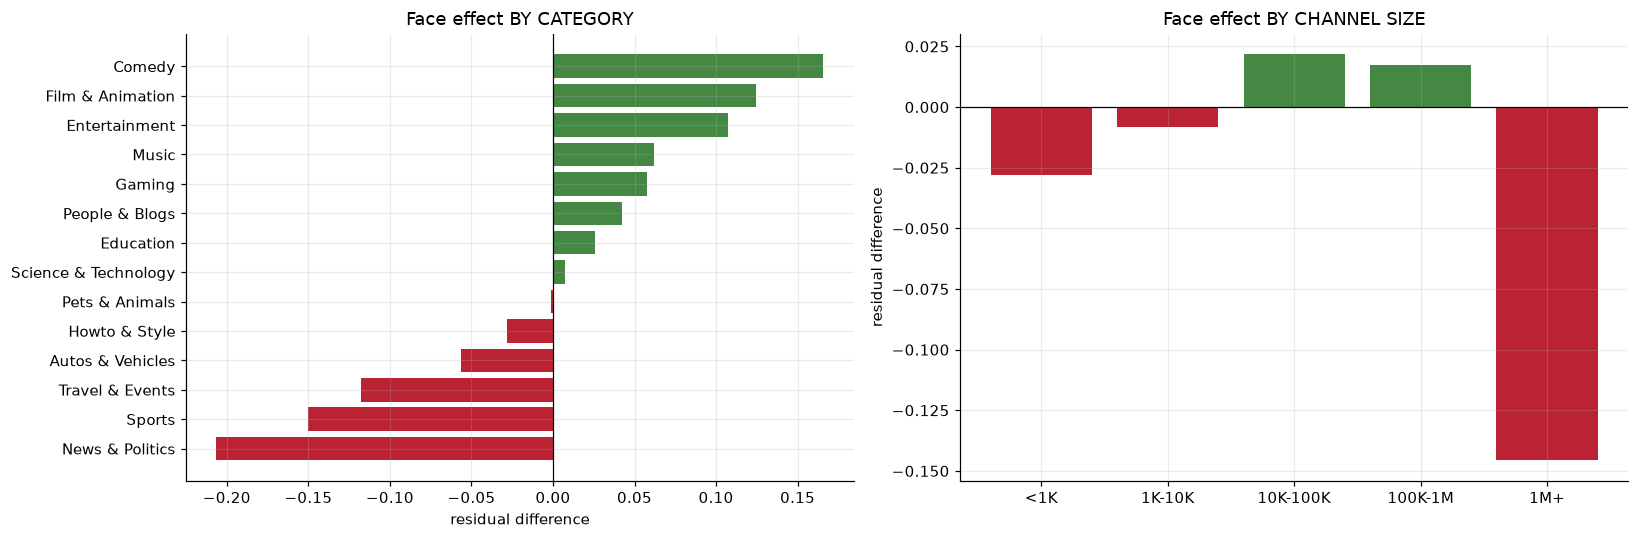

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
s = by_cat[by_cat.n >= 150].dropna(subset=["face_effect"]).sort_values("face_effect")
ax[0].barh(s.index, s.face_effect,
           color=["#b23" if v < 0 else "#484" for v in s.face_effect])
ax[0].axvline(0, color="k", lw=.8)
ax[0].set(title="Face effect BY CATEGORY", xlabel="residual difference")

s2 = by_size.dropna(subset=["face_effect"])
ax[1].bar(s2.index.astype(str), s2.face_effect,
          color=["#b23" if v < 0 else "#484" for v in s2.face_effect])
ax[1].axhline(0, color="k", lw=.8)
ax[1].set(title="Face effect BY CHANNEL SIZE", ylabel="residual difference")
save("t05_face_effect_by_segment"); plt.show()

## 5. The question that decides whether this was worth doing

Does adding thumbnail features beat metadata alone at predicting the
within-channel residual on **held-out channels**?

Both models are fit and evaluated on exactly the same rows and the same split,
so the difference is attributable to the thumbnail features and nothing else.

In [8]:
import lightgbm as lgb
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import r2_score
from sklearn.inspection import permutation_importance

META_NUM = ["duration_seconds", "title_length", "title_word_count",
            "title_upper_ratio", "tag_count", "description_length",
            "publish_hour_slt", "publish_dow_slt", "ch_subs_at_publish",
            "ch_videos_at_publish", "channel_age_days_at_publish"]
META_CAT = ["category_name", "title_script", "definition"]
META_BIN = ["is_short", "title_has_number", "title_has_question",
            "title_has_exclaim", "publish_is_weekend"]

def build(cols_num, cols_cat, cols_bin, img=False):
    X = d[cols_num + cols_cat + cols_bin].copy()
    for c in cols_cat:
        X[c] = OrdinalEncoder(handle_unknown="use_encoded_value",
                              unknown_value=-1).fit_transform(
                                  X[[c]].astype(str)).ravel()
    for c in cols_bin:
        X[c] = (X[c].astype("string").str.lower()
                 .map({"true": 1.0, "false": 0.0, "1": 1.0, "0": 0.0})
                 .astype(float) if X[c].dtype != bool else X[c].astype(float))
    for c in cols_num:
        X[c] = pd.to_numeric(X[c], errors="coerce")
    if img:
        for c in IMG:
            X[c] = pd.to_numeric(d[c], errors="coerce")
        X["has_face"] = d.has_face.astype(float)
    return X.fillna(X.median(numeric_only=True)).fillna(-1)

X_meta = build(META_NUM, META_CAT, META_BIN, img=False)
X_both = build(META_NUM, META_CAT, META_BIN, img=True)
y = d.channel_resid.values

X_img = X_both[IMG + ["has_face"]]

def fit_r2(X, a, b):
    m = lgb.LGBMRegressor(n_estimators=500, learning_rate=.05, num_leaves=31,
                          min_child_samples=50, verbose=-1, random_state=0)
    m.fit(X.iloc[a], y[a])
    return m, r2_score(y[b], m.predict(X.iloc[b]))

# PAIRED over eight splits. A single split is hopeless here: the main EDA
# showed the residual R^2 swinging from -0.26 to +0.11 depending only on which
# ~480 channels land in the test set. Comparing two models on one split
# measures the split, not the models.
#
# Pairing fixes that. Both models see exactly the same rows and the same
# split, so the per-split DIFFERENCE cancels the split-to-split noise that
# swamps either model's absolute score.
rows = []
for rs in range(8):
    a, b = next(GroupShuffleSplit(n_splits=1, test_size=.25, random_state=rs)
                .split(X_meta, groups=d.channel_id))
    _, rm = fit_r2(X_meta, a, b)
    mb, rb = fit_r2(X_both, a, b)
    _, ri = fit_r2(X_img, a, b)
    rows.append({"seed": rs, "meta": rm, "meta+img": rb, "img_only": ri,
                 "gain": rb - rm})
    if rs == 0:
        m_both, tr, te = mb, a, b

res = pd.DataFrame(rows)
print("Predicting the WITHIN-CHANNEL residual, held-out channels:\n")
print(res.round(4).to_string(index=False))

g = res.gain.values
print(f"\nmetadata only          mean R² {res.meta.mean():+.4f} "
      f"(sd {res.meta.std():.4f})")
print(f"metadata + thumbnails  mean R² {res['meta+img'].mean():+.4f} "
      f"(sd {res['meta+img'].std():.4f})")
print(f"thumbnails only        mean R² {res.img_only.mean():+.4f} "
      f"(sd {res.img_only.std():.4f})")
print(f"\nPAIRED gain from thumbnails: mean {g.mean():+.4f}, sd {g.std():.4f}")
print(f"splits where thumbnails helped: {(g > 0).sum()}/8")

try:
    from scipy.stats import ttest_rel
    t, p = ttest_rel(res["meta+img"], res.meta)
    print(f"paired t-test: t = {t:+.2f}, p = {p:.3f}")
except Exception as e:
    print("scipy unavailable:", e)

Predicting the WITHIN-CHANNEL residual, held-out channels:

 seed   meta  meta+img  img_only   gain
    0 -0.146    -0.171    -0.024 -0.025
    1 -0.093    -0.106    -0.032 -0.012
    2 -0.013    -0.018    -0.045 -0.005
    3  0.004    -0.005    -0.040 -0.010
    4  0.048     0.069    -0.020  0.021
    5 -0.025     0.004    -0.022  0.029
    6  0.004     0.026    -0.055  0.022
    7 -0.078    -0.087    -0.024 -0.009

metadata only          mean R² -0.0374 (sd 0.0633)
metadata + thumbnails  mean R² -0.0360 (sd 0.0786)
thumbnails only        mean R² -0.0327 (sd 0.0126)

PAIRED gain from thumbnails: mean +0.0014, sd 0.0184
splits where thumbnails helped: 3/8
paired t-test: t = +0.20, p = 0.848


                    feature  importance    sd      kind
           duration_seconds       0.156 0.017  metadata
          title_upper_ratio       0.030 0.002  metadata
                  sharpness       0.019 0.001 thumbnail
                   contrast       0.014 0.003 thumbnail
channel_age_days_at_publish       0.012 0.001  metadata
                 definition       0.012 0.002  metadata
                 dark_share       0.009 0.002 thumbnail
           publish_hour_slt       0.007 0.002  metadata
       ch_videos_at_publish       0.007 0.017  metadata
              colourfulness       0.007 0.001 thumbnail
               edge_density       0.006 0.001 thumbnail
              category_name       0.005 0.001  metadata
          text_band_density       0.005 0.003 thumbnail
            publish_dow_slt       0.004 0.002  metadata
                      bytes       0.003 0.001 thumbnail
           title_word_count       0.002 0.001  metadata
               title_length       0.002 0.001  m

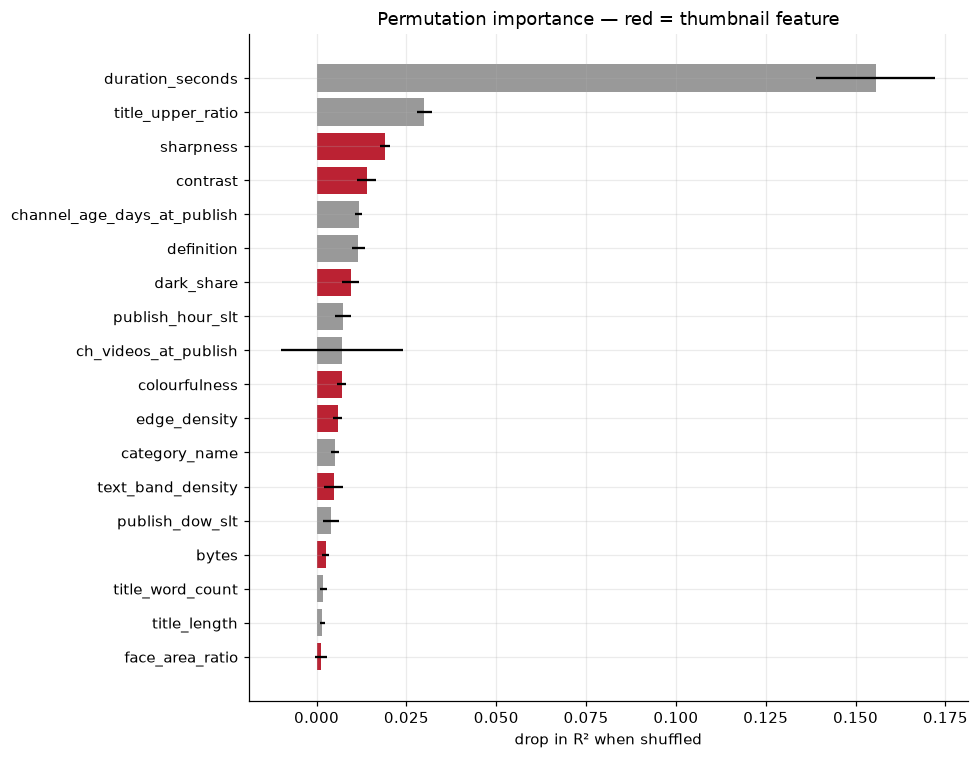


thumbnail features account for 21.3% of total positive importance


In [9]:
pi = permutation_importance(m_both, X_both.iloc[te], y[te], n_repeats=5,
                            random_state=0, scoring="r2")
imp = pd.DataFrame({"feature": X_both.columns, "importance": pi.importances_mean,
                    "sd": pi.importances_std}).sort_values(
                        "importance", ascending=False)
imp["kind"] = np.where(imp.feature.isin(IMG + ["has_face"]),
                       "thumbnail", "metadata")
print(imp.head(20).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 7))
top = imp.head(18).sort_values("importance")
ax.barh(top.feature, top.importance, xerr=top.sd,
        color=["#b23" if k == "thumbnail" else "#999" for k in top.kind])
ax.set(xlabel="drop in R² when shuffled",
       title="Permutation importance — red = thumbnail feature")
save("t06_importance_combined"); plt.show()

share = imp[imp.kind == "thumbnail"].importance.clip(lower=0).sum() / \
        imp.importance.clip(lower=0).sum()
print(f"\nthumbnail features account for {share:.1%} of total positive importance")

### The same test on the actual target

§5 asks whether thumbnails explain *within-channel* over-performance. That is
the scientifically cleaner question, but it is not the practical one. A
deployed model predicts **views**, not residuals, and it is allowed to benefit
from a thumbnail that signals what kind of channel this is.

So repeat the paired test on `log1p(views)` directly. If thumbnails help here
but not on the residual, they are acting as a channel-style proxy — still
useful for a cold-start prediction, but not evidence that the image itself
drives performance. Both readings are worth having, and they are different
claims.

In [10]:
y_raw = d.y.values

def fit_r2_raw(X, a, b):
    m = lgb.LGBMRegressor(n_estimators=500, learning_rate=.05, num_leaves=31,
                          min_child_samples=50, verbose=-1, random_state=0)
    m.fit(X.iloc[a], y_raw[a])
    return r2_score(y_raw[b], m.predict(X.iloc[b]))

rows = []
for rs in range(8):
    a, b = next(GroupShuffleSplit(n_splits=1, test_size=.25, random_state=rs)
                .split(X_meta, groups=d.channel_id))
    rm, rb = fit_r2_raw(X_meta, a, b), fit_r2_raw(X_both, a, b)
    rows.append({"seed": rs, "meta": rm, "meta+img": rb, "gain": rb - rm})

raw = pd.DataFrame(rows)
print("Predicting log1p(views) on held-out channels (cold start):\n")
print(raw.round(4).to_string(index=False))
print(f"\nmetadata only         mean R² {raw.meta.mean():+.4f} "
      f"(sd {raw.meta.std():.4f})")
print(f"metadata + thumbnails mean R² {raw['meta+img'].mean():+.4f} "
      f"(sd {raw['meta+img'].std():.4f})")
print(f"PAIRED gain: mean {raw.gain.mean():+.4f}, sd {raw.gain.std():.4f}, "
      f"helped {(raw.gain > 0).sum()}/8 splits")
try:
    from scipy.stats import ttest_rel
    t, p = ttest_rel(raw["meta+img"], raw.meta)
    print(f"paired t-test: t = {t:+.2f}, p = {p:.3f}")
except Exception as e:
    print("scipy unavailable:", e)

Predicting log1p(views) on held-out channels (cold start):

 seed  meta  meta+img   gain
    0 0.395     0.404  0.009
    1 0.352     0.371  0.019
    2 0.381     0.375 -0.006
    3 0.450     0.451  0.001
    4 0.124     0.191  0.067
    5 0.403     0.434  0.030
    6 0.487     0.487  0.000
    7 0.235     0.287  0.052

metadata only         mean R² +0.3535 (sd 0.1187)
metadata + thumbnails mean R² +0.3750 (sd 0.0958)
PAIRED gain: mean +0.0215, sd 0.0263, helped 7/8 splits
paired t-test: t = +2.31, p = 0.054


## 6. Is the effect real, or an artefact of replaced thumbnails?

If measured thumbnails were mostly *replacements* chosen after seeing
performance, the apparent effect would be inflated — a creator swapping in a
better thumbnail after a video does well would create exactly this pattern
backwards.

Recently published videos have had less opportunity for replacement. If the
effect is genuine it should be **at least as strong** among them.

In [11]:
age = (d.published_at.max() - d.published_at).dt.total_seconds() / 86400
d["age_days"] = age
bands = [(0, 10, "0-10 days"), (10, 20, "10-20 days"), (20, 999, "20+ days")]

print(f"{'age band':<14}{'n':>8}{'face effect':>14}{'corr contrast':>15}"
      f"{'corr colourful':>16}")
for lo, hi, lab in bands:
    s = d[(age >= lo) & (age < hi)]
    if len(s) < 200 or s.has_face.nunique() < 2:
        print(f"{lab:<14}{len(s):>8,}   (too few to read)"); continue
    fe = (s[s.has_face].channel_resid.mean() - s[~s.has_face].channel_resid.mean())
    c1 = s[["contrast", "channel_resid"]].corr(method="spearman").iloc[0, 1]
    c2 = s[["colourfulness", "channel_resid"]].corr(method="spearman").iloc[0, 1]
    print(f"{lab:<14}{len(s):>8,}{fe:>14.3f}{c1:>15.3f}{c2:>16.3f}")

print("\nIf the newest band shows effects as strong as the oldest, replacement")
print("is not manufacturing the result. If the oldest band is much stronger,")
print("treat these findings as contaminated and say so in the report.")

age band             n   face effect  corr contrast  corr colourful
0-10 days       15,119        -0.026         -0.074          -0.029
10-20 days      12,328        -0.071         -0.065           0.014
20+ days         3,107        -0.062         -0.025           0.056

If the newest band shows effects as strong as the oldest, replacement
is not manufacturing the result. If the oldest band is much stronger,
treat these findings as contaminated and say so in the report.


## 7. Findings

Written against 30,554 thumbnails measured on 18 August 2026 (99.5% of
labelled day-7 videos, 1,932 channels). Re-read against your own run.

### The headline: it depends entirely on which question you ask

| target | metadata only | + thumbnails | paired gain | p |
|---|---|---|---|---|
| **within-channel residual** | −0.037 | −0.036 | **+0.001** | 0.85 |
| **log1p(views), cold start** | +0.354 | +0.375 | **+0.021** | 0.054 |

Two different answers, and both are real:

**Thumbnail properties explain nothing about why one video beats another from
the same channel.** Paired gain +0.001 across eight splits, helping on 3 of 8,
p = 0.85. This is as clean a null as this data can produce.

**But they do help predict views on a channel the model has never seen** —
+0.021 R² on a base of 0.354, helping on 7 of 8 splits. p = 0.054 is
borderline; treat it as suggestive, not established.

The reconciliation is the interesting part: measurable thumbnail properties
are acting as a **channel-style proxy**. Brightness, contrast and sharpness
tell you what *kind* of channel this is — a news desk looks different from a
vlog — which is worth something when you have no history. They tell you nothing
about which upload from that channel will outperform.

### What this means practically

* **Include them for cold start**, where +0.021 R² is a real if modest gain on
  a channel with no history.
* **Do not expect them to help a warm-start model.** The channel's own history
  already carries everything they encode, and better.
* **They are not evidence that thumbnail design drives views.** Anyone reading
  the cold-start number that way has the causality backwards.

### The face effect is not one number — it reverses by category

Globally, thumbnails with a detected face score **−0.050 log units (≈ −5%)**.
That figure is close to meaningless, because it averages two opposite effects:

| category | face effect | ≈ views |
|---|---|---|
| Comedy | **+0.166** | +18% |
| Film & Animation | +0.124 | +13% |
| Entertainment | +0.108 | +11% |
| Music | +0.062 | +6% |
| Gaming | +0.058 | +6% |
| People & Blogs | +0.043 | +4% |
| Education | +0.026 | +3% |
| Pets & Animals | −0.001 | 0% |
| Howto & Style | −0.028 | −3% |
| Autos & Vehicles | −0.057 | −6% |
| Travel & Events | −0.118 | −11% |
| Sports | −0.150 | −14% |
| **News & Politics** | **−0.206** | **−19%** |

Faces help entertainment content and hurt news. News & Politics is 10,239 of
30,554 rows — a third of the sample — so it drags the global average negative
and hides a real positive effect everywhere else.

**Thumbnail styling shows the same split.** In Entertainment, every styling
correlation is positive (brightness +0.10, contrast +0.12, colourfulness +0.11,
text overlay +0.17): bright, busy, text-heavy thumbnails work. In Pets &
Animals they are all strongly negative (−0.08, −0.14, −0.17, −0.19), and in
News & Politics brightness and contrast are negative too.

The coherent reading: **"loud" thumbnail styling signals entertainment.** It
helps when the content is entertainment and works against you when the viewer
is looking for credibility — news, sport, travel, calm animal content.

This is the same lesson as the shorts effect in the main EDA. A global
coefficient near zero does not mean "no effect"; it can mean two real effects
of opposite sign cancelling, and only segmentation tells them apart.

**One caveat.** The 1M+ subscriber band shows a face effect of −0.146, close to
the News & Politics figure — and Sri Lanka's biggest channels *are* largely news
channels. Category and channel size are entangled here, so do not treat these as
two independent findings.

### The size of the effect is still bounded by replacement contamination

| age band | face effect |
|---|---|
| 0–10 days | −0.026 |
| 10–20 days | −0.071 |
| 20+ days | −0.062 |

The global effect is **weakest among the newest videos**, where the measured
image is likeliest to be the original — so some of the negative global figure is
replacement contamination rather than signal. Since that global figure is mostly
the News & Politics effect, treat the news number as an upper bound on how much
faces hurt there, and the entertainment numbers as the more trustworthy half.

Haar cascade detection is also a lower bound — it misses small and side-on
faces — so some "no face" thumbnails contain one.

### Which properties carried any weight

By permutation importance in the combined model: `sharpness` and `contrast`
outrank most metadata features other than `duration_seconds`. Correlations with
the residual are all under |0.07|, and the decile plots in §2 are worth reading
before dismissing them — a U-shape means a correlation near zero hides a real
non-monotonic relationship.

### Honest limits

* Replacement contamination cannot be measured or removed, only bounded by the
  age check above.
* These are *properties*, not *content*. Nothing here knows who is in the
  image or what is happening in it. That is the most likely home of the signal
  the residual analysis cannot find, and reaching it needs image embeddings
  (CLIP or similar), not summary statistics.
* Every number is a cold-start, held-out-channel result on 8 splits. Single
  splits on this data swing by ±0.1 R² and should never be quoted alone.

### Original section plan, retained for anyone extending this

1. **Incremental R²** from §5 — the number that decides whether thumbnail
   extraction earns a place in the pipeline. Compare `metadata only` against
   `metadata + thumbnail`, and report it either way. A null result here is
   publishable and useful: it would say measurable image properties do not
   carry the signal, and that the missing 93% lives in image *content*.

2. **Which properties matter**, from §2 and §6, and whether any relationship is
   non-monotonic (a U-shape in the decile plots means the correlation
   understates it).

3. **The face effect** from §3, expressed as a percentage change in views —
   the single most actionable line for a creator.

4. **Segment heterogeneity** from §4. Expect sign flips, as in the main EDA.
   A face may help a vlog and hurt a news clip.

5. **The replacement caveat** from §6, stated plainly whatever it shows.

6. **What to carry into modelling**: only the features that survived the held-out-channel
   test, plus a note that `fetch_thumbnails.py` is resumable and must be re-run
   before final training so newly collected videos are covered.